# 1. TÌM THẺ

## Tiền xử lý Mask, Tạo Symlink & Sinh file YAML
Đoạn mã này dùng để chuẩn bị dữ liệu huấn luyện cho YOLO. Nó chuyển đổi các ảnh mask (ảnh nhị phân/đen trắng đánh dấu vùng thẻ) thành định dạng bounding box của YOLO (tọa độ tâm, chiều rộng, chiều cao chuẩn hóa) và tạo file cấu hình .yaml.

In [10]:
import cv2
import os
import glob

# 1. ĐƯỜNG DẪN GỐC TỪ KAGGLE INPUT
# Chỉ định thư mục chứa ảnh gốc và ảnh mask tương ứng
mask_dir = '/kaggle/input/datasets/mailngdmd/midv-2020-mask/midv2020_processed/images' 
image_dir = '/kaggle/input/datasets/mailngdmd/midv-2020-mask/midv2020_processed/masks'

# Kiểm tra an toàn: Đảm bảo đường dẫn tồn tại trước khi chạy logic xử lý
if not os.path.exists(mask_dir):
    print(f"LỖI: Không tìm thấy thư mục mask: {mask_dir}")
elif not os.path.exists(image_dir):
    print(f"LỖI: Không tìm thấy thư mục image: {image_dir}")
else:
    # 2. TẠO CẤU TRÚC THƯ MỤC ĐỂ TRAIN YOLO
    # YOLO yêu cầu thư mục 'images' và 'labels' nằm cùng một cấp
    base_dir = '/kaggle/working/data_card'
    os.makedirs(f'{base_dir}/images/train', exist_ok=True)
    os.makedirs(f'{base_dir}/labels/train', exist_ok=True)

    count = 0
    MAX_SAMPLES = 400 # Giới hạn số lượng ảnh để train nhanh (có thể tăng lên nếu muốn)

    print("Đang xử lý tạo Label và Symlink...")
    for mask_name in os.listdir(mask_dir):
        if count >= MAX_SAMPLES: break
        # Bỏ qua các file không phải định dạng ảnh
        if not mask_name.endswith(('.png', '.jpg', '.tif')): continue

        mask_path = os.path.join(mask_dir, mask_name)
        # Đọc ảnh mask dưới dạng ảnh xám (Grayscale)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None: continue

        # Tiền xử lý mask: Chuyển mọi pixel > 1 thành 255 (trắng hoàn toàn), còn lại là 0 (đen)
        _, thresh = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)
        
        # Tìm đường viền (contours) của các vùng màu trắng (vùng thẻ)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours: continue

        # Lấy đường viền có diện tích lớn nhất (giả định thẻ chiếm diện tích lớn nhất trong mask)
        largest_contour = max(contours, key=cv2.contourArea)
        
        # Tạo một hình chữ nhật bao quanh đường viền đó (Bounding Box)
        # x, y: tọa độ góc trên cùng bên trái. w, h: chiều rộng và chiều cao.
        x, y, w, h = cv2.boundingRect(largest_contour)

        # Xử lý tọa độ sang định dạng của YOLO:
        # YOLO cần: <class_id> <center_x> <center_y> <width> <height> (tất cả được chuẩn hóa từ 0-1)
        img_h, img_w = mask.shape
        txt_name = mask_name.rsplit('.', 1)[0] + '.txt'
        txt_path = f'{base_dir}/labels/train/{txt_name}'

        with open(txt_path, 'w') as f:
            # class_id = 0 (vì chỉ có 1 class là 'card'). Tính tâm x, tâm y và chuẩn hóa bằng cách chia cho img_w, img_h.
            f.write(f"0 {(x + w/2)/img_w:.6f} {(y + h/2)/img_h:.6f} {w/img_w:.6f} {h/img_h:.6f}\n")
        
        # BƯỚC B NÂNG CẤP: Tìm ảnh gốc dựa trên tên của ảnh mask (Bất chấp đuôi mở rộng)
        mask_base_name = mask_name.rsplit('.', 1)[0]
        # Sử dụng glob để quét tìm ảnh gốc tương ứng trong thư mục image_dir
        matching_images = glob.glob(os.path.join(image_dir, f"{mask_base_name}.*"))
        
        if matching_images:
            src_img_path = matching_images[0] # Lấy file đầu tiên khớp tên
            dst_img_path = f'{base_dir}/images/train/{os.path.basename(src_img_path)}'
            
            # Tạo Symlink (lối tắt) thay vì copy ảnh để tiết kiệm dung lượng ổ cứng
            if not os.path.exists(dst_img_path):
                os.symlink(src_img_path, dst_img_path) 
                count += 1

    print(f"Hoàn tất! Đã link {count} ảnh và tạo {count} file nhãn.")

    # 3. TẠO FILE YAML ĐỂ YOLO BIẾT CÁCH ĐỌC DỮ LIỆU
    if count > 0:
        yaml_content = f"""
        path: {base_dir}
        train: images/train
        val: images/train # Tạm dùng chung tập train làm tập validation
        nc: 1 # Số lượng classes (Number of classes)
        names: ['card'] # Tên của class
        """
        with open('/kaggle/working/data_card.yaml', 'w') as f:
            f.write(yaml_content)
        print("Đã tạo xong file cấu hình data_card.yaml. Sẵn sàng train!")
    else:
        print("CẢNH BÁO: Vẫn không tìm thấy cặp ảnh/nhãn nào để link!")

Đang xử lý tạo Label và Symlink...
Hoàn tất! Đã link 400 ảnh và tạo 400 file nhãn.
Đã tạo xong file cấu hình data_card.yaml. Sẵn sàng train!


## Cài đặt và Bắt đầu Train
Đoạn này cài đặt thư viện Ultralytics và tiến hành huấn luyện mô hình YOLOv8 nano trên tập dữ liệu đã chuẩn bị.

In [11]:
# Cài đặt thư viện Ultralytics (chứa YOLOv8), -q để ẩn các log cài đặt cho gọn màn hình
!pip install ultralytics -q

from ultralytics import YOLO

# Khởi tạo mô hình pre-trained YOLOv8 bản nano (n) - bản nhẹ và nhanh nhất
model = YOLO('yolov8n.pt') 

print("=== BẮT ĐẦU HUẤN LUYỆN YOLO DETECTOR ===")
# Tiến hành huấn luyện mô hình
results = model.train(
    data='/kaggle/working/data_card.yaml', # Trỏ tới file cấu hình vừa tạo
    epochs=50,                             # Số vòng lặp qua toàn bộ dataset
    imgsz=640,                             # Resize mọi ảnh về 640x640 trong lúc train
    device=0                               # Sử dụng GPU 0 (nếu có)
)
print("=== HUẤN LUYỆN HOÀN TẤT ===")

=== BẮT ĐẦU HUẤN LUYỆN YOLO DETECTOR ===
Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_card.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=

## Chạy thử và trực quan hóa
Sau khi train xong, dùng mô hình tốt nhất (best.pt) để quét ảnh thực tế. Sau đó dùng tỷ lệ tọa độ cứng (hard-coded ratios) để cắt vùng Số thẻ và Họ tên.

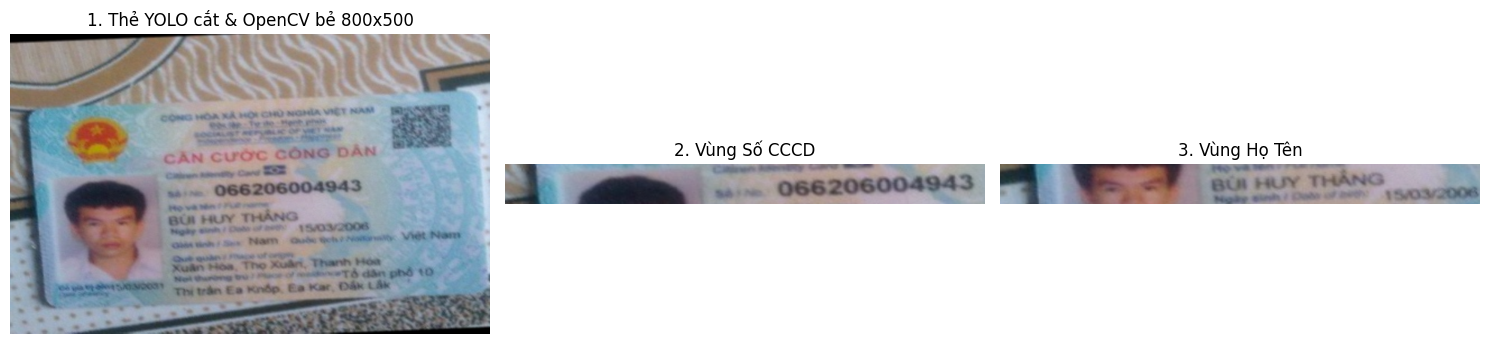

In [12]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load trọng số (weights) tốt nhất mà mô hình vừa huấn luyện được
# Lưu ý: Cần đảm bảo đường dẫn 'runs/detect/train/...' khớp với kết quả thực tế của phiên chạy
yolo_model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

def extract_info_fields(image_path):
    img = cv2.imread(image_path)
    if img is None: 
        print("Không đọc được ảnh!")
        return None, None, None
        
    # OpenCV mặc định đọc ảnh hệ màu BGR, cần chuyển sang RGB để YOLO và Matplotlib hiển thị đúng màu
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # YOLO dự đoán (Inference). 
    # conf=0.01: Mức tự tin rất thấp, nhận diện mọi vùng có > 1% xác suất là thẻ (Nên tăng lên khoảng 0.5 trong thực tế)
    results = yolo_model(img_rgb, conf=0.01, verbose=False)
    
    # Lấy tọa độ bounding box từ kết quả dự đoán, chuyển dữ liệu từ GPU (nếu có) về CPU và thành mảng Numpy
    boxes = results[0].boxes.xyxy.cpu().numpy()
    
    if len(boxes) == 0:
        print("YOLO không tìm thấy thẻ nào trong ảnh này.")
        return None, None, None
        
    # Ép kiểu tọa độ về số nguyên (x_min, y_min, x_max, y_max)
    x1, y1, x2, y2 = map(int, boxes[0])
    
    # Dùng numpy slicing để cắt riêng phần thẻ ra khỏi nền ảnh gốc
    card_only = img_rgb[y1:y2, x1:x2]
    
    # Chuẩn hóa kích thước thẻ về độ phân giải cố định để việc cắt theo tỷ lệ phần trăm được chính xác
    STD_WIDTH, STD_HEIGHT = 800, 500
    card_resized = cv2.resize(card_only, (STD_WIDTH, STD_HEIGHT))
    
    # Cắt các vùng thông tin dựa trên tỷ lệ vàng (đã đo đạc trước trên kích thước 800x500)
    
    # 1. Cắt vùng Số CCCD (ID)
    y1_id, y2_id = int(STD_HEIGHT * 0.46), int(STD_HEIGHT * 0.56)
    x1_id, x2_id = int(STD_WIDTH * 0.00), int(STD_WIDTH * 0.75)
    crop_id = card_resized[y1_id:y2_id, x1_id:x2_id]
    
    # 2. Cắt vùng Họ Tên
    y1_name, y2_name = int(STD_HEIGHT * 0.57), int(STD_HEIGHT * 0.67)
    x1_name, x2_name = int(STD_WIDTH * 0.00), int(STD_WIDTH * 0.75)
    crop_name = card_resized[y1_name:y2_name, x1_name:x2_name]
    
    return card_resized, crop_id, crop_name

# --- TEST TRÊN 1 ẢNH THỰC TẾ ---
test_image_path = '/kaggle/input/datasets/nhungnguyen1899/cccd-dataset-10k-ver3/ocr_dataset_2/train/images/aug_1.jpg' 

card_img, id_img, name_img = extract_info_fields(test_image_path)

# Trực quan hóa kết quả bằng Matplotlib
if card_img is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(card_img)
    axes[0].set_title("1. Thẻ YOLO cắt & OpenCV bẻ 800x500")
    axes[0].axis('off')
    
    axes[1].imshow(id_img)
    axes[1].set_title("2. Vùng Số CCCD")
    axes[1].axis('off')
    
    axes[2].imshow(name_img)
    axes[2].set_title("3. Vùng Họ Tên")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

## Chạy vòng lặp hàng loạt
Áp dụng hàm xử lý trên để tự động bóc tách vùng ID và Tên cho dữ liệu ảnh gốc và chuẩn bị cho các mô hình OCR nhận diện chữ (như VietOCR, Tesseract, v.v.).

In [13]:
import os
import tqdm # Thư viện vẽ thanh tiến trình (progress bar) trực quan

# --- ĐIỀN ĐƯỜNG DẪN TỚI THƯ MỤC CHỨA DỮ LIỆU LỚN CỦA BẠN ---
input_dir = '/kaggle/input/datasets/nhungnguyen1899/cccd-dataset-10k-ver3/ocr_dataset_2/train/images'

# Khởi tạo thư mục đầu ra chứa dữ liệu đã cắt
out_id_dir = '/kaggle/working/dataset_ocr/ids/'
out_name_dir = '/kaggle/working/dataset_ocr/names/'
os.makedirs(out_id_dir, exist_ok=True)
os.makedirs(out_name_dir, exist_ok=True)

# Lọc và lấy danh sách toàn bộ các file ảnh trong thư mục
image_files = [f for f in os.listdir(input_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
success_count = 0

print(f"Bắt đầu cắt {len(image_files)} ảnh...")

# tqdm.tqdm bọc quanh danh sách sẽ tự động hiển thị thanh tiến trình ở console
for filename in tqdm.tqdm(image_files):
    img_path = os.path.join(input_dir, filename)
    
    # Tái sử dụng hàm đã định nghĩa ở trên. Ký tự '_' dùng để hứng giá trị card_resized nhưng không sử dụng.
    _, id_img, name_img = extract_info_fields(img_path)
    
    # Chỉ xử lý khi YOLO tìm thấy thẻ và cắt thành công
    if id_img is not None and name_img is not None:
        # Chuyển ảnh màu RGB về ảnh xám (Grayscale). 
        # Các mô hình OCR thường làm việc tốt hơn trên ảnh xám vì giảm được nhiễu từ màu nền.
        id_gray = cv2.cvtColor(id_img, cv2.COLOR_RGB2GRAY)
        name_gray = cv2.cvtColor(name_img, cv2.COLOR_RGB2GRAY)
        
        # Lưu các vùng ảnh đã xử lý xuống ổ cứng với tiền tố phân biệt
        cv2.imwrite(os.path.join(out_id_dir, f'id_{filename}'), id_gray)
        cv2.imwrite(os.path.join(out_name_dir, f'name_{filename}'), name_gray)
        success_count += 1

print(f"\nHoàn tất! Đã cắt thành công {success_count}/{len(image_files)} ảnh.")
print("Dữ liệu đã nằm gọn gàng tại: /kaggle/working/dataset_ocr/")

Bắt đầu cắt 7000 ảnh...


  1%|          | 72/7000 [00:01<02:21, 48.79it/s]

YOLO không tìm thấy thẻ nào trong ảnh này.


  1%|▏         | 100/7000 [00:01<02:16, 50.68it/s]

YOLO không tìm thấy thẻ nào trong ảnh này.


...

YOLO không tìm thấy thẻ nào trong ảnh này.


 97%|█████████▋| 6812/7000 [02:18<00:04, 41.45it/s]

YOLO không tìm thấy thẻ nào trong ảnh này.
YOLO không tìm thấy thẻ nào trong ảnh này.


100%|██████████| 7000/7000 [02:22<00:00, 49.19it/s]


Hoàn tất! Đã cắt thành công 6935/7000 ảnh.
Dữ liệu đã nằm gọn gàng tại: /kaggle/working/dataset_ocr/


# 2. ĐỌC THẺ

## Bước 1: Xây dựng Từ điển (Vocabulary)
Bước này thiết lập bảng chữ cái cần nhận diện. Một điểm cực kỳ quan trọng trong OCR sử dụng CTC Loss là phải có một token <BLANK> (thường đặt ở index 0) để đại diện cho khoảng trống giữa các ký tự.

In [14]:
import os
import cv2
import json
import torch
import numpy as np
import tqdm
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn

# ==========================================
# BƯỚC 1: XÂY DỰNG TỪ ĐIỂN (VOCABULARY)
# ==========================================

# Tập hợp các ký tự cần nhận diện: A-Z, số 0-9, dấu khoảng trắng (space) 
# và toàn bộ các chữ cái tiếng Việt có dấu (định dạng IN HOA)
VIETNAMESE_CHARS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 ÀÁÂÃÈÉÊÌÍÒÓÔÕÙÚÝĂĐĨŨƠƯẠẢẤẦẨẪẬẮẰẲẴẶẸẺẼẾỀỂỄỆỈỊỌỎỐỒỔỖỘỚỜỞỠỢỤỦỨỪỬỮỰỲỴỶỸ"

# Tạo bộ từ điển ánh xạ từ Ký tự sang ID (Bắt đầu từ 1, vì 0 dành cho <BLANK>)
char2id = {c: i + 1 for i, c in enumerate(VIETNAMESE_CHARS)}

# Thêm token <BLANK> bắt buộc cho thuật toán CTC Loss (Connectionist Temporal Classification)
char2id['<BLANK>'] = 0

# Tạo từ điển ngược lại ánh xạ từ ID sang Ký tự để dùng khi dự đoán (decode)
id2char = {i: c for c, i in char2id.items()}

print(f"Tổng số class (ký tự) mô hình cần phân loại: {len(char2id)}")

# Lưu từ điển ra file JSON để sau này sử dụng cho quá trình Inference (dự đoán thực tế)
vocab_path = '/kaggle/working/char2id_vietnamese.json'
with open(vocab_path, 'w', encoding='utf-8') as f:
    json.dump(char2id, f, ensure_ascii=False)
    
print("Đã lưu từ điển tiếng Việt thành công!")

Tổng số class (ký tự) mô hình cần phân loại: 105
Đã lưu từ điển tiếng Việt thành công!


## Bước 2: Đóng gói PyTorch Dataset & DataLoader
Phần này định nghĩa cách đọc ảnh, chuyển đổi ảnh về dạng tensor và chuẩn bị nhãn cho quá trình huấn luyện.

In [15]:
# ==========================================
# BƯỚC 2: ĐÓNG GÓI DATASET & DATALOADER
# ==========================================

class CCCDCombinedDataset(Dataset):
    def __init__(self, id_dir, name_dir, label_dict_id, label_dict_name):
        self.samples = []  # Danh sách chứa tuple: (đường_dẫn_ảnh, nhãn_text)
        
        # 1. Nạp toàn bộ dữ liệu ảnh Số CCCD
        for img_name, text in label_dict_id.items():
            img_path = os.path.join(id_dir, img_name)
            if os.path.exists(img_path):
                self.samples.append((img_path, text))
                
        # 2. Nạp toàn bộ dữ liệu ảnh Họ Tên
        for img_name, text in label_dict_name.items():
            img_path = os.path.join(name_dir, img_name)
            if os.path.exists(img_path):
                self.samples.append((img_path, text))
                
        print(f"Đã tạo Dataset gộp thành công với tổng cộng {len(self.samples)} mẫu dữ liệu!")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, text = self.samples[idx]

        # Đọc ảnh dưới dạng ảnh xám (Grayscale)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        # Xử lý lỗi nếu ảnh không đọc được: Trả về ảnh đen trống
        if img is None:
            img = np.zeros((32, 128), dtype=np.uint8)

        # Tiền xử lý ảnh: 
        # Resize ép cứng về kích thước (128, 32) (Rộng x Cao) để khớp với kiến trúc đầu vào của mạng CRNN
        img = cv2.resize(img, (128, 32))
        
        # Chuẩn hóa giá trị pixel về khoảng [0, 1]
        img = img.astype(np.float32) / 255.0
        
        # Chuyển đổi sang PyTorch Tensor và thêm chiều channel (1, H, W)
        img = torch.from_numpy(img).unsqueeze(0)  # Shape: (1, 32, 128)

        # Xử lý Nhãn: Chuyển chuỗi text thành danh sách các ID tương ứng
        target = [char2id[c] for c in text if c in char2id]
        
        # Trả về: Ảnh, Nhãn (Tensor), Độ dài của nhãn, Chuỗi text gốc
        return img, torch.tensor(target, dtype=torch.long), torch.tensor(len(target), dtype=torch.long), text

# Hàm Collate: Xử lý batching cho dữ liệu có độ dài sequence khác nhau
def ctc_collate_fn(batch):
    images, targets, target_lengths, texts = zip(*batch)
    
    # Gom các ảnh lại thành 1 batch tensor: Shape (batch_size, 1, 32, 128)
    images = torch.stack(images, 0)
    
    # CTCLoss yêu cầu tất cả targets trong batch gom lại thành một mảng 1D duy nhất
    targets = torch.cat(targets, 0) 
    
    # Độ dài tương ứng của từng target trong batch
    target_lengths = torch.stack(target_lengths, 0)
    
    return images, targets, target_lengths, texts


# ==========================================
# CHUẨN BỊ DỮ LIỆU THỰC NGHIỆM
# ==========================================

label_dir_goc = '/kaggle/input/datasets/nhungnguyen1899/cccd-dataset-10k-ver3/ocr_dataset_2/train/labels'
img_directory = '/kaggle/working/dataset_ocr/ids/'

label_dict_id = {}
label_dict_name = {}

# Đọc tất cả các file .txt trong thư mục nhãn gốc
for label_filename in os.listdir(label_dir_goc):
    if label_filename.endswith('.txt'):
        # 1. Trích xuất tên gốc của file (ví dụ: 'aug_0' từ 'aug_0.jpg.txt')
        base_name = label_filename.replace('.txt', '').replace('.jpg', '')
        
        # 2. Định nghĩa tên file ảnh tương ứng cho phần Số và phần Tên
        cropped_id_name = f'id_{base_name}.jpg'
        cropped_name_name = f'name_{base_name}.jpg'
        
        # 3. Đọc nội dung text bên trong
        label_path = os.path.join(label_dir_goc, label_filename)
        with open(label_path, 'r', encoding='utf-8') as f:
            text_content = f.read().strip() 
            
        # 4. Tách Số CCCD và Họ Tên
        # Hàm split(' ', 1) cắt chuỗi tại khoảng trắng đầu tiên
        # VD: "75091011605 LƯU VĂN THẢO" -> ['75091011605', 'LƯU VĂN THẢO']
        if ' ' in text_content:
            parts = text_content.split(' ', 1)
            so_cccd = parts[0].strip()
            ho_ten = parts[1].strip()
            
            # Cập nhật vào dictionary
            label_dict_id[cropped_id_name] = so_cccd
            label_dict_name[cropped_name_name] = ho_ten
        else:
            print(f"Cảnh báo: File {label_filename} không đúng định dạng (thiếu khoảng trắng).")

# Khởi tạo Dataloader
id_dir = '/kaggle/working/dataset_ocr/ids/'
name_dir = '/kaggle/working/dataset_ocr/names/'

dataset = CCCDCombinedDataset(id_dir, name_dir, label_dict_id, label_dict_name)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=ctc_collate_fn)

Đã tạo Dataset gộp thành công với tổng cộng 13870 mẫu dữ liệu!


## Bước 3: Định nghĩa Kiến trúc mạng CRNN
Mạng CRNN (Convolutional Recurrent Neural Network) kết hợp CNN để trích xuất đặc trưng hình ảnh và RNN để nắm bắt ngữ cảnh tuần tự của các ký tự.

In [16]:
# ==========================================
# BƯỚC 3: ĐỊNH NGHĨA MẠNG CRNN
# ==========================================

class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()
        
        # 1. Khối CNN (Trích xuất đặc trưng không gian)
        # Quá trình giảm kích thước qua các lớp MaxPool:
        # Input: (1, 32, 128) [C, H, W]
        # Pool 1: 2x2 -> (64, 16, 64)
        # Pool 2: 2x2 -> (128, 8, 32)
        # Pool 3: 2x1 -> (256, 4, 32)  (Lưu ý: Chỉ giảm chiều cao, giữ nguyên chiều rộng để giữ chiều dài chuỗi sequence)
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d((2, 1))
        )
        
        # 2. Khối RNN (Trích xuất đặc trưng tuần tự / ngữ cảnh)
        # Bidirectional LSTM giúp mô hình đọc chuỗi ký tự từ cả 2 chiều trái->phải và phải->trái
        self.rnn1 = nn.LSTM(1024, 256, bidirectional=True, batch_first=True)
        self.rnn2 = nn.LSTM(512, 256, bidirectional=True, batch_first=True)
        
        # 3. Lớp phân loại (Fully Connected)
        # Output từ Bi-LSTM là 512 (2 chiều * 256 hidden_size). Phân loại ra số lượng ký tự (bao gồm <BLANK>).
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        # Trôi qua mạng CNN: (batch, 1, 32, 128) -> (batch, 256, 4, 32)
        x = self.cnn(x)
        b, c, h, w = x.size()
        
        # Chuẩn bị dữ liệu cho RNN
        # 1. Đổi chỗ: (batch, channels, height, width) -> (batch, width, height, channels)
        # 2. View: (batch, width, height * channels) -> (batch, 32, 4 * 256) = (batch, 32, 1024)
        # Ở đây seq_len = 32 (tương ứng với chiều rộng W sau khi qua CNN)
        x = x.permute(0, 3, 2, 1).contiguous().view(b, w, -1) 
        
        # Trôi qua mạng RNN (Chỉ lấy tensor đầu ra, bỏ qua hidden states)
        x, _ = self.rnn1(x)
        x, _ = self.rnn2(x)
        
        # Lớp phân loại ký tự: (batch, seq_len=32, num_classes)
        x = self.fc(x)
        
        # ĐỊNH DẠNG BẮT BUỘC CHO CTC LOSS TRONG PYTORCH:
        # Hàm CTC Loss mặc định yêu cầu input có shape: (seq_len, batch_size, num_classes)
        return x.permute(1, 0, 2) 

# --- KHỞI TẠO ---
# Số lớp phân loại = Số lượng ký tự trong từ điển (đã bao gồm <BLANK>)
model = CRNN(num_classes=len(char2id))
model = model.to('cuda')  # Đẩy mô hình lên GPU

# CTC Loss với index của token blank là 0
criterion = nn.CTCLoss(blank=0) 

# AdamW là biến thể của Adam tích hợp weight decay tốt hơn, rất phù hợp cho OCR
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

print("Mô hình CRNN đã sẵn sàng trên GPU!")

Mô hình CRNN đã sẵn sàng trên GPU!


## Bước 4: Vòng lặp Huấn luyện (Train Loop) & Giải mã
Quá trình huấn luyện tính toán CTC Loss. Quá trình giải mã (Decoding) sẽ sử dụng thuật toán Greedy Decoding để chuyển output xác suất thành chuỗi văn bản con người đọc được.

In [17]:
# ==========================================
# BƯỚC 4: HUẤN LUYỆN VÀ GIẢI MÃ
# ==========================================

def train_model(model, dataloader, optimizer, criterion, num_epochs=30):
    model.train()
    print("Bắt đầu train CRNN...")
    
    for epoch in range(num_epochs):
        total_loss = 0
        progress_bar = tqdm.tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for images, targets, target_lengths, _ in progress_bar:
            images = images.to('cuda')
            batch_size = images.size(0)
            
            # 1. Forward pass (Dự đoán)
            # preds có kích thước: (seq_len=32, batch_size, num_classes)
            preds = model(images) 
            
            # 2. Định nghĩa độ dài dự đoán của mô hình
            # Với ảnh width=128, sau khi qua CNN chiều rộng giảm còn 32. Do đó seq_len luôn là 32.
            preds_size = torch.full((batch_size,), 32, dtype=torch.long)
            
            # 3. Tính toán độ trễ (Loss)
            # CTCLoss yêu cầu log_softmax trên chiều cuối cùng (num_classes, dim=2)
            loss = criterion(preds.log_softmax(2), targets, preds_size, target_lengths)
            
            # 4. Backward & Optimize (Cập nhật trọng số)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
        
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1} kết thúc. Loss trung bình: {avg_loss:.4f}")
        
        # Lưu trữ Checkpoint sau mỗi 5 epochs để tránh mất tiến trình
        if (epoch + 1) % 5 == 0:
            torch.save(model.state_dict(), f'/kaggle/working/crnn_model_epoch_{epoch+1}.pth')
            print(f"Đã lưu model tại epoch {epoch+1}")

# Gọi hàm huấn luyện
train_model(model, dataloader, optimizer, criterion, num_epochs=30)


def decode_predictions(preds):
    """
    Hàm giải mã đầu ra của mạng CRNN (Sử dụng phương pháp Greedy Decoding).
    Input: Tensor chứa xác suất phân bố của các ký tự tại từng time-step.
    """
    # 1. Lấy chỉ số (ID) có xác suất cao nhất tại mỗi bước thời gian (time-step)
    # preds.softmax(2) có shape: (seq_len, 1, num_classes) -> lấy max theo dim=2
    _, max_indices = torch.max(preds.softmax(2), 2)
    
    # Chuyển tensor về numpy array dạng 1D
    max_indices = max_indices.squeeze(1).detach().cpu().numpy()
    
    # 2. Giải mã CTC (CTC Decoding Rule):
    # - Bỏ qua các token <BLANK> (ID = 0)
    # - Gộp các token giống nhau nằm liền kề (Ví dụ: "H-H-O-A-A" -> "HOA")
    decoded = []
    for i in range(len(max_indices)):
        # Nếu không phải khoảng trắng VÀ (là ký tự đầu tiên HOẶC khác ký tự liền trước nó)
        if max_indices[i] != 0 and (i == 0 or max_indices[i] != max_indices[i-1]):
            decoded.append(max_indices[i])
            
    # Chuyển ID ngược lại thành Ký tự (dựa trên id2char đã xây ở Bước 1)
    return "".join([id2char[i] for i in decoded])

Bắt đầu train CRNN...


Epoch 1/30: 100%|██████████| 434/434 [00:14<00:00, 30.42it/s, loss=2.8] 


Epoch 1 kết thúc. Loss trung bình: 3.4086


Epoch 2/30: 100%|██████████| 434/434 [00:14<00:00, 30.78it/s, loss=2.43]


Epoch 2 kết thúc. Loss trung bình: 2.7128


...

Epoch 28 kết thúc. Loss trung bình: 0.2085


Epoch 29/30: 100%|██████████| 434/434 [00:14<00:00, 30.83it/s, loss=0.0564]


Epoch 29 kết thúc. Loss trung bình: 0.1956


Epoch 30/30: 100%|██████████| 434/434 [00:14<00:00, 30.84it/s, loss=0.321] 


Epoch 30 kết thúc. Loss trung bình: 0.1685
Đã lưu model tại epoch 30


# 3. THỰC TẾ

Ảnh vào: Người dùng chụp ảnh -> Ảnh thô.

YOLO: Model YOLO best.pt của bạn sẽ tìm và cắt ra vùng ảnh CCCD.

OpenCV: Bẻ phẳng và cắt ra ảnh Số và Tên.

CRNN: Nạp model crnn_model.pth để đọc ảnh -> Trả về chuỗi text.

Kết quả: Trả về JSON chứa {"cccd_number": "075091...", "full_name": "..."}.

Kết quả trích xuất: {
  "cccd_number": "15395321036",
  "full_name": "HOÀNG THỊ THẢO",
  "status": "success"
}


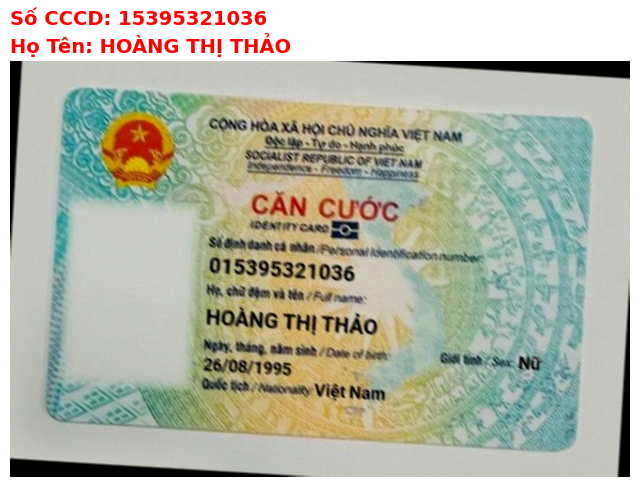

In [18]:
import cv2
import torch
import numpy as np
import json
import matplotlib.pyplot as plt
from ultralytics import YOLO
# Lưu ý: Class CRNN cần được định nghĩa hoặc import từ file model của bạn trước đó
# from models import CRNN 

class CCCDProcessor:
    def __init__(self, yolo_path, crnn_path, char2id_path):
        """
        Khởi tạo pipeline xử lý CCCD bao gồm 2 phần:
        1. YOLO: Dò tìm và cắt vùng chứa thẻ CCCD.
        2. CRNN: Nhận diện chữ (OCR) trên các vùng thông tin đã cắt.
        """
        # --- 1. Load Model YOLO (Bộ phận tìm thẻ) ---
        self.yolo_model = YOLO(yolo_path)
        
        # --- 2. Load Model CRNN (Bộ phận đọc chữ) ---
        # Tải từ điển ký tự (char2id) và tạo từ điển ngược (id2char)
        self.char2id = self._load_json(char2id_path)
        self.id2char = {v: k for k, v in self.char2id.items()}
        
        # Khởi tạo kiến trúc CRNN với số lớp bằng số lượng ký tự trong từ điển
        self.crnn = CRNN(num_classes=len(self.char2id))
        
        # Load trọng số đã train vào model và chuyển sang chế độ dự đoán (eval)
        self.crnn.load_state_dict(torch.load(crnn_path, map_location='cpu'))
        self.crnn.eval()

    def _load_json(self, path):
        """Hàm hỗ trợ đọc file JSON."""
        with open(path, 'r', encoding='utf-8') as f: 
            return json.load(f)

    def predict(self, image_path):
        """
        Thực hiện toàn bộ quy trình: Đọc ảnh -> YOLO tìm thẻ -> Cắt vùng -> OCR đọc chữ.
        """
        # ==========================================
        # BƯỚC 1: ĐỌC ẢNH VÀ DÙNG YOLO ĐỂ TÌM THẺ
        # ==========================================
        img = cv2.imread(image_path)
        if img is None:
            return {"error": "Không đọc được ảnh từ đường dẫn đã cho."}

        # YOLOv8 yêu cầu ảnh đầu vào chuẩn RGB để dự đoán chính xác
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Dự đoán với ngưỡng tự tin (confidence) = 0.01, tắt log (verbose=False)
        results = self.yolo_model(img_rgb, conf=0.01, verbose=False)
        boxes = results[0].boxes.xyxy.cpu().numpy()
        
        if len(boxes) == 0: 
            return {"error": "YOLO không tìm thấy thẻ CCCD trong ảnh."}
        
        # Lấy tọa độ bounding box đầu tiên (x_min, y_min, x_max, y_max)
        x1, y1, x2, y2 = map(int, boxes[0])
        
        # Cắt lấy phần thẻ CCCD trên ảnh gốc (dạng BGR để khớp với hàm OCR dùng cv2)
        card_bgr = img[y1:y2, x1:x2]
        
        # ==========================================
        # BƯỚC 2: BẺ PHẲNG VÀ CẮT CÁC VÙNG THÔNG TIN
        # ==========================================
        # Đưa ảnh thẻ về kích thước chuẩn để dễ dàng dùng tọa độ tương đối
        STD_WIDTH, STD_HEIGHT = 800, 500
        card_resized = cv2.resize(card_bgr, (STD_WIDTH, STD_HEIGHT))
        
        # 2.1 Cắt vùng Số CCCD (dựa trên tỷ lệ kích thước chuẩn)
        y1_id, y2_id = int(STD_HEIGHT * 0.46), int(STD_HEIGHT * 0.56)
        x1_id, x2_id = int(STD_WIDTH * 0.00), int(STD_WIDTH * 0.75)
        crop_id = card_resized[y1_id:y2_id, x1_id:x2_id]
        
        # 2.2 Cắt vùng Họ và Tên (dựa trên tỷ lệ kích thước chuẩn)
        y1_name, y2_name = int(STD_HEIGHT * 0.57), int(STD_HEIGHT * 0.67)
        x1_name, x2_name = int(STD_WIDTH * 0.00), int(STD_WIDTH * 0.75)
        crop_name = card_resized[y1_name:y2_name, x1_name:x2_name]
        
        # ==========================================
        # BƯỚC 3: DÙNG CRNN ĐỂ ĐỌC CHỮ (OCR)
        # ==========================================
        # Gọi hàm _ocr_inference để nhận dạng chữ cho từng vùng
        id_text = self._ocr_inference(crop_id)
        name_text = self._ocr_inference(crop_name)
        
        # Trả về kết quả JSON hoàn chỉnh
        return {
            "cccd_number": id_text, 
            "full_name": name_text, 
            "status": "success"
        }

    def _ocr_inference(self, img_crop):
        """
        Tiền xử lý ảnh vùng cắt và đưa vào mạng CRNN để dự đoán chuỗi ký tự.
        """
        # Chuyển ảnh sang ảnh xám và resize về kích thước chuẩn cho CRNN (128x32)
        gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(gray, (128, 32)).astype(np.float32) / 255.0
        
        # Chuyển numpy array thành tensor và thêm chiều cho batch và channel: [1, 1, 32, 128]
        tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
        
        with torch.no_grad():
            preds = self.crnn(tensor)
            
            # Decode kết quả từ mạng sử dụng CTC (Connectionist Temporal Classification)
            _, max_indices = torch.max(preds.softmax(2), 2)
            max_indices = max_indices.squeeze(1).numpy()
            decoded = []
            
            for i in range(len(max_indices)):
                # Bỏ qua token <BLANK> (mặc định là 0) và các ký tự trùng lặp đứng liền kề
                if max_indices[i] != 0 and (i == 0 or max_indices[i] != max_indices[i-1]):
                    decoded.append(self.id2char[max_indices[i]])
                    
            return "".join(decoded)

# ==========================================
# PHẦN SỬ DỤNG VÀ KIỂM THỬ THỰC TẾ
# ==========================================
if __name__ == "__main__":
    # 1. Khai báo các đường dẫn (Đảm bảo file tồn tại)
    yolo_path = '/kaggle/working/runs/detect/train/weights/best.pt'
    crnn_path = '/kaggle/working/crnn_model_epoch_30.pth'
    char2id_path = '/kaggle/working/char2id_vietnamese.json'
    img_test_path = '/kaggle/input/datasets/nhungnguyen1899/cccd-dataset-10k-ver3/ocr_dataset_2/val/images/aug_1111.jpg'

    # 2. Khởi tạo Processor
    processor = CCCDProcessor(yolo_path, crnn_path, char2id_path)
    
    # 3. Dự đoán
    result = processor.predict(img_test_path)
    print("Kết quả trích xuất:", json.dumps(result, ensure_ascii=False, indent=2))
    
    # 4. Hiển thị ảnh kèm theo kết quả
    img_test = cv2.imread(img_test_path)
    if img_test is not None:
        img_rgb = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
        
        # Setup Figure để vẽ
        plt.figure(figsize=(8, 6))
        plt.imshow(img_rgb)
        plt.axis('off') # Tắt trục tọa độ
        
        # Gắn text kết quả làm title của ảnh để tiện theo dõi
        title_text = f"Số CCCD: {result.get('cccd_number', 'N/A')}\nHọ Tên: {result.get('full_name', 'N/A')}"
        plt.title(title_text, fontsize=14, color='red', fontweight='bold', loc='left')
        
        # Hiển thị
        plt.show()
    else:
        print("Không thể hiển thị ảnh do sai đường dẫn.")